In [1]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path
Libraries loaded successfully


In [ ]:
# ======================================================
# Respiration + BORIS paths (VALENCE SETS ONLY)
# ======================================================

# Base paths for valence data
valence_h5_base = r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\Resp_h5"
valence_boris_base = r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\boris_csv_RI1 and RI2"

# --- Valence (RI1, RI2, BLRI) ---
# Using relative paths from base; adjust file names as needed
resp_paths_valence = {
    "RI1_3_6": os.path.join(valence_h5_base, "RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"),
    "RI2_3_6": os.path.join(valence_h5_base, "RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"),
    "RI1_4_7": os.path.join(valence_h5_base, "RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"),
    "RI2_4_7": os.path.join(valence_h5_base, "RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"),
    "RI1_2_3": os.path.join(valence_h5_base, "RI1_s2_3_p5_3_nRB3_20250622_104059_merged.h5"),
    "RI2_2_3": os.path.join(valence_h5_base, "RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"),
    "RI1_4_8": os.path.join(valence_h5_base, "RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"),
    "RI2_4_8": os.path.join(valence_h5_base, "RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"),
    "RI1_1_1": os.path.join(valence_h5_base, "RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"),
    "RI2_1_1": os.path.join(valence_h5_base, "RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"),
    "RI1_1_2": os.path.join(valence_h5_base, "RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"),
    "RI2_1_2": os.path.join(valence_h5_base, "RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"),
    "RI1_2_4": os.path.join(valence_h5_base, "RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"),
    "RI2_2_4": os.path.join(valence_h5_base, "RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"),
    "RI1_3_5": os.path.join(valence_h5_base, "RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"),
    "RI2_3_5": os.path.join(valence_h5_base, "RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"),
    # Baseline recordings (pre-valence)
    "BLRI_1_1": os.path.join(valence_h5_base, "BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5"),
    "BLRI_1_2": os.path.join(valence_h5_base, "BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5"),
    "BLRI_2_3": os.path.join(valence_h5_base, "BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5"),
    "BLRI_2_4": os.path.join(valence_h5_base, "BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5"),
    "BLRI_3_6": os.path.join(valence_h5_base, "BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"),
    "BLRI_4_7": os.path.join(valence_h5_base, "BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"),
    "BLRI_4_8": os.path.join(valence_h5_base, "BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5"),
}


boris_paths_valence = {
    "RI1_3_6": os.path.join(valence_boris_base, "RI1_s3_6_p5_3_nRB3_HEEPS.csv"),
    "RI2_3_6": os.path.join(valence_boris_base, "RI2_s3_6_p_5_3_nRB3_2025062.csv"),
    "RI1_4_7": os.path.join(valence_boris_base, "RI1_s4_7_p5_2_nRB3_HEEPS.csv"),
    "RI2_4_7": os.path.join(valence_boris_base, "RI2_s4_7_p5_2_nRB3_HEEPS.csv"),
    "RI1_2_3": os.path.join(valence_boris_base, "RI1_s2_3_p5_3_nRB3_20250622_104059_ss.csv"),
    "RI2_2_3": os.path.join(valence_boris_base, "RI2_s2_3_p5_3_nRB3_20250622_1102116.1_ss.csv"),
    "RI1_4_8": os.path.join(valence_boris_base, "RI1_s4_8_p5_1_nRB3_HEEPS.csv"),
    "RI2_4_8": os.path.join(valence_boris_base, "RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv"),
    "RI1_1_1": os.path.join(valence_boris_base, "RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv"),
    "RI2_1_1": os.path.join(valence_boris_base, "RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv"),
    "RI1_1_2": os.path.join(valence_boris_base, "RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv"),
    "RI2_1_2": os.path.join(valence_boris_base, "RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv"),
    "RI1_2_4": os.path.join(valence_boris_base, "RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv"),
    "RI2_2_4": os.path.join(valence_boris_base, "RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv"),
    "RI2_3_5": os.path.join(valence_boris_base, "RI2_s3_5_p5_4_nRB3_20250621.csv"),
}

In [3]:
# Global rank labels for AIM1 valence cohort (RI1/RI2 / BLRI trial keys).
# Cagemate rank rows use rename_map canonical names and _SUB/_DOM only (interaction-specific).
rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

In [4]:
# ======================================================
# Summary check (VALENCE ONLY)
# ======================================================

def summarize_paths(resp_dict, boris_dict, label):
    resp_set = set(resp_dict.keys())
    boris_set = set(boris_dict.keys())
    missing = resp_set - boris_set
    print(f"\n {label} summary")
    print(f"Resp files: {len(resp_set)} | BORIS files: {len(boris_set)} | No BORIS: {len(missing)}")
    if missing:
        print("Missing trials:", ", ".join(sorted(missing)))

# ======================================================
# Organized summaries by experiment type (VALENCE ONLY)
# ======================================================

# --- Split out valence subsets for clarity ---
resp_paths_interactions = {k: v for k, v in resp_paths_valence.items() if k.startswith(("RI1", "RI2"))}
resp_paths_blri = {k: v for k, v in resp_paths_valence.items() if k.startswith("BLRI")}

# Filter BORIS dicts by matching prefixes
boris_paths_valence = {k: v for k, v in boris_paths_valence.items() if k.startswith(("RI1", "RI2"))}

summarize_paths(resp_paths_valence, boris_paths_valence, "Valence (RI1/RI2)")

print(f"\nTotal respiration files (valence only): {len(resp_paths_valence)}")
print(f"Total BORIS files (valence only): {len(boris_paths_valence)}")

# Note: BLRI (pre-valence baseline) processing will be attempted but skipped if missing
print(f"\nPre-valence Baseline (BLRI) files available: {len(resp_paths_blri)}")


 Valence (RI1/RI2) summary
Resp files: 23 | BORIS files: 15 | No BORIS: 8
Missing trials: BLRI_1_1, BLRI_1_2, BLRI_2_3, BLRI_2_4, BLRI_3_6, BLRI_4_7, BLRI_4_8, RI1_3_5

Total respiration files (valence only): 23
Total BORIS files (valence only): 15

Pre-valence Baseline (BLRI) files available: 7


In [5]:
def recording_meta_from_h5(h5_path):
    """Recording = .h5 basename; MouseSubject = subject pair from `_s{n}_{m}_` in filename."""
    base = os.path.basename(str(h5_path))
    m = re.search(r"_s(\d+)_(\d+)_", base, flags=re.IGNORECASE)
    mouse = f"{m.group(1)}_{m.group(2)}" if m else np.nan
    return base, mouse


def build_window_feature_matrix(
    resp_paths_interactions,
    boris_paths_valence,
    resp_paths_blri,
    rank_map,
    data_type="rodentAirflow",
    target_srate=400,
    window_sec=3.0,
    n_windows_per_session=100,
    min_breaths_per_window=5,
    random_state=42,
):
    all_rows = []

    # =========================================================
    # A. Interaction sessions (RI1 / RI2)
    # =========================================================
    for trial, h5_path in resp_paths_interactions.items():
        print(f"\n[Interaction] {trial}")

        signal, time, fs, meta = load_clean_resp_signal(
            h5_path,
            target_rate=target_srate
        )
        if signal is None:
            print("  ❌ Load failed")
            continue

        bm = fit_bm_session(signal, fs, data_type=data_type)
        if bm is None:
            continue

        print(f"  ✓ {len(bm.inhaleOnsets)} breaths detected in session")

        subj      = "_".join(trial.split("_")[1:3])
        condition = trial.split("_")[0]
        rank      = rank_map.get(subj, np.nan)
        recording_file, mouse_from_file = recording_meta_from_h5(h5_path)

        # sample random windows from full session
        windows = sample_random_nonoverlapping_windows(
            time=time,
            signal=signal,
            window_dur=window_sec,
            n_windows=n_windows_per_session,
            seed=random_state,
            allow_partial_if_short=False,
        )

        if len(windows) == 0:
            print("  ⚠️ No usable full windows")
            continue

        window_rows = extract_features_from_windows(
            bm=bm,
            windows=windows,
            min_breaths_per_window=min_breaths_per_window,
        )

        print(f"  ✓ {len(window_rows)} usable windows")

        # optional BORIS summary per session
        n_bouts_by_behavior = {}
        total_bout_dur_by_behavior = {}

        if trial in boris_paths_valence:
            boris_df = load_clean_boris(boris_paths_valence[trial])
            if not boris_df.empty:
                for beh, grp in boris_df.groupby("Behavior"):
                    safe_beh = str(beh).replace(" ", "_")
                    n_bouts_by_behavior[f"n_bouts_{safe_beh}"] = len(grp)
                    total_bout_dur_by_behavior[f"total_dur_{safe_beh}"] = grp["Duration"].sum()

        for row in window_rows:
            row.update({
                "Trial": trial,
                "Subject": subj,
                "Recording": recording_file,
                "MouseSubject": mouse_from_file,
                "Condition": condition,
                "Rank": rank,
                "Type": "Interaction",
                "session_duration_sec": time[-1] - time[0],
                "n_breaths_total": len(bm.inhaleOnsets),
                "WindowSec": window_sec,
            })
            row.update(n_bouts_by_behavior)
            row.update(total_bout_dur_by_behavior)
            all_rows.append(row)

    # =========================================================
    # B. Baseline sessions (BLRI)
    # =========================================================
    for trial, h5_path in resp_paths_blri.items():
        print(f"\n[Baseline] {trial}")

        signal, time, fs, meta = load_clean_resp_signal(
            h5_path,
            target_rate=target_srate
        )
        if signal is None:
            print("  ❌ Load failed")
            continue

        bm = fit_bm_session(signal, fs, data_type=data_type)
        if bm is None:
            continue

        print(f"  ✓ {len(bm.inhaleOnsets)} breaths detected in session")

        subj      = "_".join(trial.split("_")[1:3])
        condition = trial.split("_")[0]
        rank      = rank_map.get(subj, np.nan)
        recording_file, mouse_from_file = recording_meta_from_h5(h5_path)

        windows = sample_random_nonoverlapping_windows(
            time=time,
            signal=signal,
            window_dur=window_sec,
            n_windows=n_windows_per_session,
            seed=random_state,
            allow_partial_if_short=False,
        )

        if len(windows) == 0:
            print("  ⚠️ No usable full windows")
            continue

        window_rows = extract_features_from_windows(
            bm=bm,
            windows=windows,
            min_breaths_per_window=min_breaths_per_window,
        )

        print(f"  ✓ {len(window_rows)} usable windows")

        for row in window_rows:
            row.update({
                "Trial": trial,
                "Subject": subj,
                "Recording": recording_file,
                "MouseSubject": mouse_from_file,
                "Condition": condition,
                "Rank": rank,
                "Type": "Baseline",
                "session_duration_sec": time[-1] - time[0],
                "n_breaths_total": len(bm.inhaleOnsets),
                "WindowSec": window_sec,
            })
            all_rows.append(row)

    # =========================================================
    # C. Assemble
    # =========================================================
    if not all_rows:
        print("\n⚠️ No rows collected.")
        return pd.DataFrame()

    master_df = pd.DataFrame(all_rows).reset_index(drop=True)

    print(f"\n✅ Window feature matrix: {len(master_df)} rows × {len(master_df.columns)} cols")
    print(f"   Trials : {master_df['Trial'].nunique()}")
    print(f"   Recordings : {master_df['Recording'].nunique()}")
    print(f"   Subjects   : {master_df['Subject'].nunique()} (trial key)")
    print(f"   MouseSubj  : {master_df['MouseSubject'].nunique()} (from filename)")
    print(f"   Type dist :\n{master_df['Type'].value_counts()}")
    return master_df

In [13]:
window_df = build_window_feature_matrix(
    resp_paths_interactions = resp_paths_interactions,
    boris_paths_valence     = boris_paths_valence,
    resp_paths_blri         = resp_paths_blri,
    rank_map                = rank_map,
    data_type               = "rodentAirflow",
    target_srate            = 400,
    window_sec              = 3.0,
    n_windows_per_session   = 100,
    min_breaths_per_window  = 4,
    random_state            = 42,
)


[Interaction] RI1_3_6
original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
  ✓ 3902 breaths detected in session
  ✓ 100 usable windows

[Interaction] RI2_3_6
original resp len: 12200094
original fs: 20000.0
duration_sec: 610.0047
expected duration from len/fs: 610.0047
  ✓ 2506 breaths detected in session
  ✓ 83 usable windows

[Interaction] RI1_4_7
original resp len: 12583112
original fs: 20000.0
duration_sec: 629.1556
expected duration from len/fs: 629.1556
  ✓ 4118 breaths detected in session
  ✓ 100 usable windows

[Interaction] RI2_4_7
original resp len: 12129332
original fs: 20000.0
duration_sec: 606.4666
expected duration from len/fs: 606.4666
  ✓ 3592 breaths detected in session
  ✓ 100 usable windows

[Interaction] RI1_2_3
original resp len: 12058916
original fs: 20000.0
duration_sec: 602.9458
expected duration from len/fs: 602.9458
  ✓ 3654 breaths detected in session
  ✓ 98 usable windows

[Interaction] RI2_2_3
orig

In [14]:
window_df.head(23)

,WindowID,Start,Stop,Duration,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,mean_inhale_vol,mean_exhale_vol,mean_tidal_vol_proxy,cv_inhale_vol,ventilation_proxy,pct_breaths_with_inhale_pause,mean_inhale_pause_dur_sec,cv_inhale_pause_dur,inhale_pause_duty_cycle,pct_breaths_with_exhale_pause,mean_exhale_pause_dur_sec,cv_exhale_pause_dur,exhale_pause_duty_cycle,inhale_duty_cycle,exhale_duty_cycle,Trial,Subject,Recording,MouseSubject,Condition,Rank,Type,session_duration_sec,n_breaths_total,WindowSec,n_bouts_anogenital_sniffing,n_bouts_body_sniffing,n_bouts_facial_sniffing,total_dur_anogenital_sniffing,total_dur_body_sniffing,total_dur_facial_sniffing
0,0,0.0,3.0,3.0,23,8.110599,0.123295,0.395847,0.070326,0.686864,0.047283,0.164203,1.487356,1768.609817,-1157.014047,0.277502,78831.242365,36932.542940,115763.785306,0.488165,9.389137e+05,0.000000,0.0000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.570387,0.383490,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.27,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
1,1,12.0,15.0,3.0,30,9.805579,0.101983,0.286920,0.045417,0.495634,0.051500,0.398650,0.881877,1292.692763,-1233.501638,0.406402,42686.203379,42972.532913,85658.736292,0.583736,8.399335e+05,0.000000,0.0000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.445337,0.504987,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.27,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
2,2,18.0,21.0,3.0,24,8.148804,0.122717,0.447254,0.063854,0.667111,0.054271,0.429149,1.176583,1444.108153,-1066.021541,0.248866,56169.481664,38887.470925,95056.952588,0.460222,7.746005e+05,0.000000,0.0000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.520335,0.442242,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.27,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
3,3,21.0,24.0,3.0,30,10.139860,0.098621,0.115992,0.040667,0.142797,0.055583,0.346975,0.731634,1126.167480,-1046.388673,0.279587,32766.613224,39706.729659,72473.342883,0.373237,7.348696e+05,0.000000,0.0000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.412354,0.563607,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.27,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
4,4,27.0,30.0,3.0,28,9.254499,0.108056,0.270498,0.047054,0.456620,0.055536,0.347103,0.847267,1162.672678,-957.341416,0.270349,37575.630047,36570.975907,74146.605953,0.470774,6.861897e+05,0.000000,0.0000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.435457,0.513955,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.27,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
5,5,36.0,39.0,3.0,28,9.083263,0.110093,0.178856,0.048214,0.345021,0.056786,0.262272,0.849057,1246.242935,-989.628517,0.312847,42063.721417,38037.463235,80101.184651,0.461879,7.275801e+05,0.000000,0.0000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.437943,0.515800,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.27,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
6,6,39.0,42.0,3.0,26,8.841733,0.113100,0.296579,0.043365,0.160643,0.064712,0.467704,0.670134,1091.579087,-980.537872,0.370618,34054.124601,43098.008636,77152.133237,0.493189,6.821586e+05,0.000000,0.0000,NaN,0.000000,0.038462,0.027500,NaN,0.009352,0.383425,0.572162,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.27,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
7,7,48.0,51.0,3.0,16,5.940594,0.168333,0.601456,0.060313,0.368386,0.072500,0.545220,0.831897,1144.376063,-768.452320,0.359672,41325.346506,33232.157725,74557.504231,0.423380,4.429159e+05,0.000000,0.0000,NaN,0.000000,0.125000,0.206250,0.684848,0.153156,0.358292,0.430693,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.27,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
8,8,51.0,54.0,3.

In [20]:
window_df['n_breaths'].min()

np.int64(4)

In [15]:
len(window_df)

2207

In [21]:
window_df.to_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\raw-breathmetrics-features-session-3sec-subjectnames")

original resp len: 12583112
original fs: 20000.0
duration_sec: 629.1556
expected duration from len/fs: 629.1556


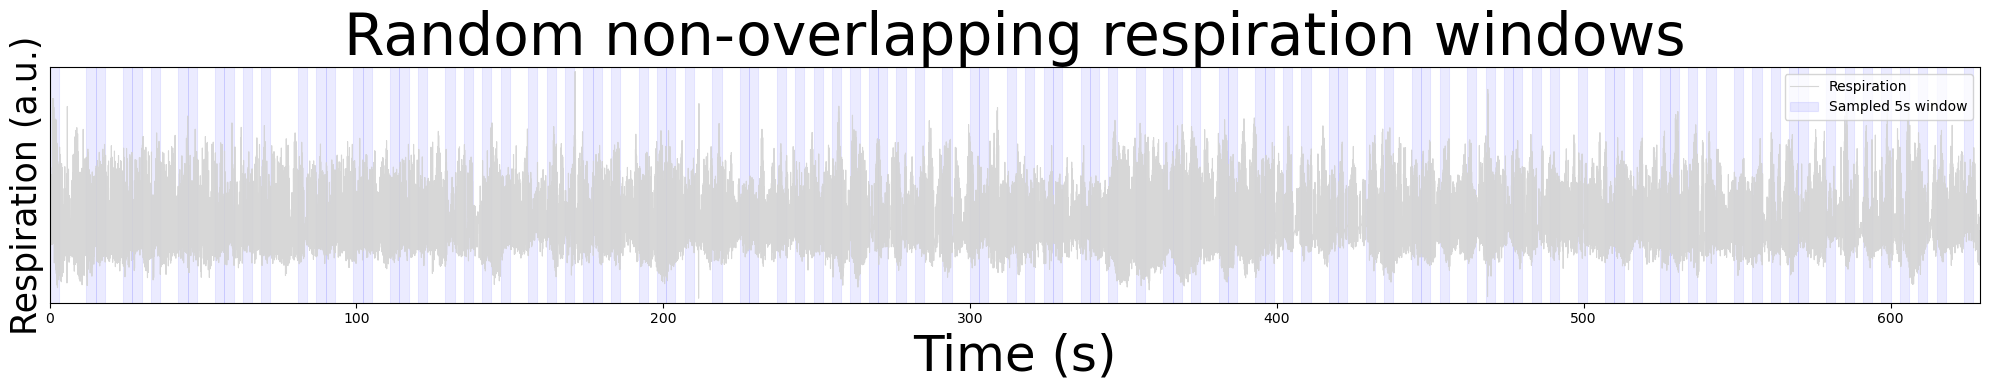

In [17]:
# Plot one recording with random 5-sec non-overlapping windows highlighted

# Use requested trial and seed for reproducible visualization
trial = "RI1_4_7"
h5_path = resp_paths_interactions[trial]

# Load respiration signal exactly like feature extraction pipeline
signal, time, fs, meta = load_clean_resp_signal(h5_path, target_rate=400)

# Match your feature-extraction settings
window_sec = 3.0
n_windows = 100
random_state = 4219172438

windows = sample_random_nonoverlapping_windows(
    time=time,
    signal=signal,
    window_dur=window_sec,
    n_windows=n_windows,
    seed=random_state,
    allow_partial_if_short=False,
)

fig, ax = plt.subplots(figsize=(20, 4), facecolor="none")
ax.set_facecolor("none")
ax.plot(time, signal, color="lightgrey", lw=0.8, alpha=0.9, label="Respiration")

# Shade sampled windows with visible outlines
for i, (start, stop) in enumerate(windows):
    ax.axvspan(
        start,
        stop,
        facecolor="blue",
        edgecolor="blue",
        alpha=0.08,
        lw=0.8,
        label="Sampled 5s window" if i == 0 else None
    )

# Only slightly tighten y-limits
y_min, y_max = signal.min(), signal.max()
pad = 0.02 * (y_max - y_min)
ax.set_ylim(y_min - pad, y_max + pad)

ax.set_xlabel("Time (s)", fontsize=36)
ax.set_ylabel("Respiration (a.u.)", fontsize=25)
ax.set_yticks([])
ax.set_title("Random non-overlapping respiration windows", fontsize=42)

ax.legend(loc="upper right")
ax.margins(x=0)

fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# ===============================
# HELPER FUNCTIONS (UNCHANGED)
# ===============================

def _as_1d_int_array(x, allow_nan=False):
    arr = np.asarray(x).ravel()
    if allow_nan:
        return arr.astype(float)
    return arr.astype(int)


def _get_attr_if_exists(obj, names, required=False, default=None):
    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name), name
    if required:
        raise AttributeError(f"Could not find any of these attributes on bm: {names}")
    return default, None


# ===============================
# NEW: IMPROVED PAUSE SELECTION
# ===============================

def _find_breath_with_pause(df):
    """Pick the breath where the pause is most prominent relative to breath duration."""

    def _best(subset, dur_col, ref_col="breath_dur"):
        subset = subset.copy()
        subset["pause_frac"] = subset[dur_col] / subset[ref_col].replace(0, np.nan)
        subset = subset[subset[dur_col] > 0.02]  # remove noise (<20ms)
        if subset.empty:
            return None
        return int(subset.sort_values("pause_frac", ascending=False).iloc[0]["breath_idx"])

    has_inhale = df[
        df["inhale_pause_on"].notna() &
        ~df["inhale_pause_on"].apply(np.isnan) &
        df["inhale_pause_dur"].notna()
    ]
    if not has_inhale.empty:
        result = _best(has_inhale, "inhale_pause_dur")
        if result is not None:
            return result

    has_exhale = df[
        df["exhale_pause_on"].notna() &
        ~df["exhale_pause_on"].apply(np.isnan) &
        df["exhale_pause_dur"].notna()
    ]
    if not has_exhale.empty:
        return _best(has_exhale, "exhale_pause_dur")

    return None


# ===============================
# NEW: PAUSE-AWARE WINDOW
# ===============================

def _segment_window_pause(row, signal_len, pad_frac=0.20, min_pad=10):
    """
    Always includes full breath cycle + pause endpoints.
    Prevents pause clipping.
    """
    key_points = [
        int(row["inhale_on"]),
        int(row["exhale_on"]),
        int(row["inhale_off"]),
        int(row["exhale_off"]),
    ]

    if not np.isnan(row["inhale_pause_on"]):
        key_points.append(int(row["inhale_pause_on"]))
    if not np.isnan(row["exhale_pause_on"]):
        key_points.append(int(row["exhale_pause_on"]))
    if not np.isnan(row["next_inhale_on"]):
        key_points.append(int(row["next_inhale_on"]))

    lo = min(key_points)
    hi = max(key_points)

    pad = max(min_pad, int((hi - lo) * pad_frac))

    start = max(0, lo - pad)
    stop = min(signal_len, hi + pad)

    return start, stop

def _plot_respiratory_pause(ax, signal, time, row):
    start, stop = _segment_window_pause(
        row,
        len(signal),
        pad_frac=0.20,
        time=time,
        left_shift_sec=0.05,
    )
    t = time[start:stop]
    s = signal[start:stop]

    ax.plot(t, s, color="black", lw=2.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylabel("Airflow (a.u.)", fontsize=16)

    pause_fill = "#B279A2"
    pause_text = "#7A4F84"

    ymin, ymax = np.nanmin(s), np.nanmax(s)
    yr = ymax - ymin if ymax > ymin else 1.0

    # Put the arrow above the waveform, but shorten the overall top headroom
    y_ann_top = ymax + 0.08 * yr
    y_ann_lower = ymax + 0.035 * yr

    drew_first = False

    if not np.isnan(row["inhale_pause_on"]):
        p = int(row["inhale_pause_on"])
        b = int(row["exhale_on"])
        pause_start_t = time[p]
        pause_end_t = time[b]

        ax.axvspan(pause_start_t, pause_end_t, alpha=0.45, color=pause_fill)

        dur_sec = row["inhale_pause_dur"]
        if not np.isnan(dur_sec):
            ax.annotate(
                "",
                xy=(pause_end_t, y_ann_top),
                xytext=(pause_start_t, y_ann_top),
                arrowprops=dict(arrowstyle="<->", lw=1.4, color=pause_text),
            )
        drew_first = True

    if not np.isnan(row["exhale_pause_on"]) and not np.isnan(row["next_inhale_on"]):
        p = int(row["exhale_pause_on"])
        nxt = int(row["next_inhale_on"])
        pause_start_t = time[p]
        pause_end_t = time[nxt]

        ax.axvspan(pause_start_t, pause_end_t, alpha=0.45, color=pause_fill)

        dur_sec = row["exhale_pause_dur"]
        if not np.isnan(dur_sec):
            y_ann = y_ann_lower if drew_first else y_ann_top
            ax.annotate(
                "",
                xy=(pause_end_t, y_ann),
                xytext=(pause_start_t, y_ann),
                arrowprops=dict(arrowstyle="<->", lw=1.4, color=pause_text),
            )

    # Shorter window above the signal than before
    ax.set_ylim(ymin - 0.08 * yr, ymax + 0.12 * yr)

    pause_handle = mpatches.Patch(color=pause_fill, alpha=0.45, label="Pause")
    ax.legend(
        handles=[pause_handle],
        frameon=False,
        loc="upper right",
        bbox_to_anchor=(0.96, 1.02),
        fontsize=12,
        handletextpad=0.5,
    )

    ax.tick_params(axis="both", labelsize=12)

original resp len: 12089585
original fs: 20000.0
duration_sec: 604.4791
expected duration from len/fs: 604.47925
Using BM fields: {'inhale_onsets': 'inhaleOnsets', 'exhale_onsets': 'exhaleOnsets', 'inhale_offsets': 'inhaleOffsets', 'exhale_offsets': 'exhaleOffsets', 'inhale_pause_onsets': 'inhalePauseOnsets', 'exhale_pause_onsets': 'exhalePauseOnsets', 'inhale_peaks': 'inhalePeaks', 'exhale_troughs': 'exhaleTroughs'}
Selected breaths: {'combined': 1379, 'breath_rate_series_start': 3911}


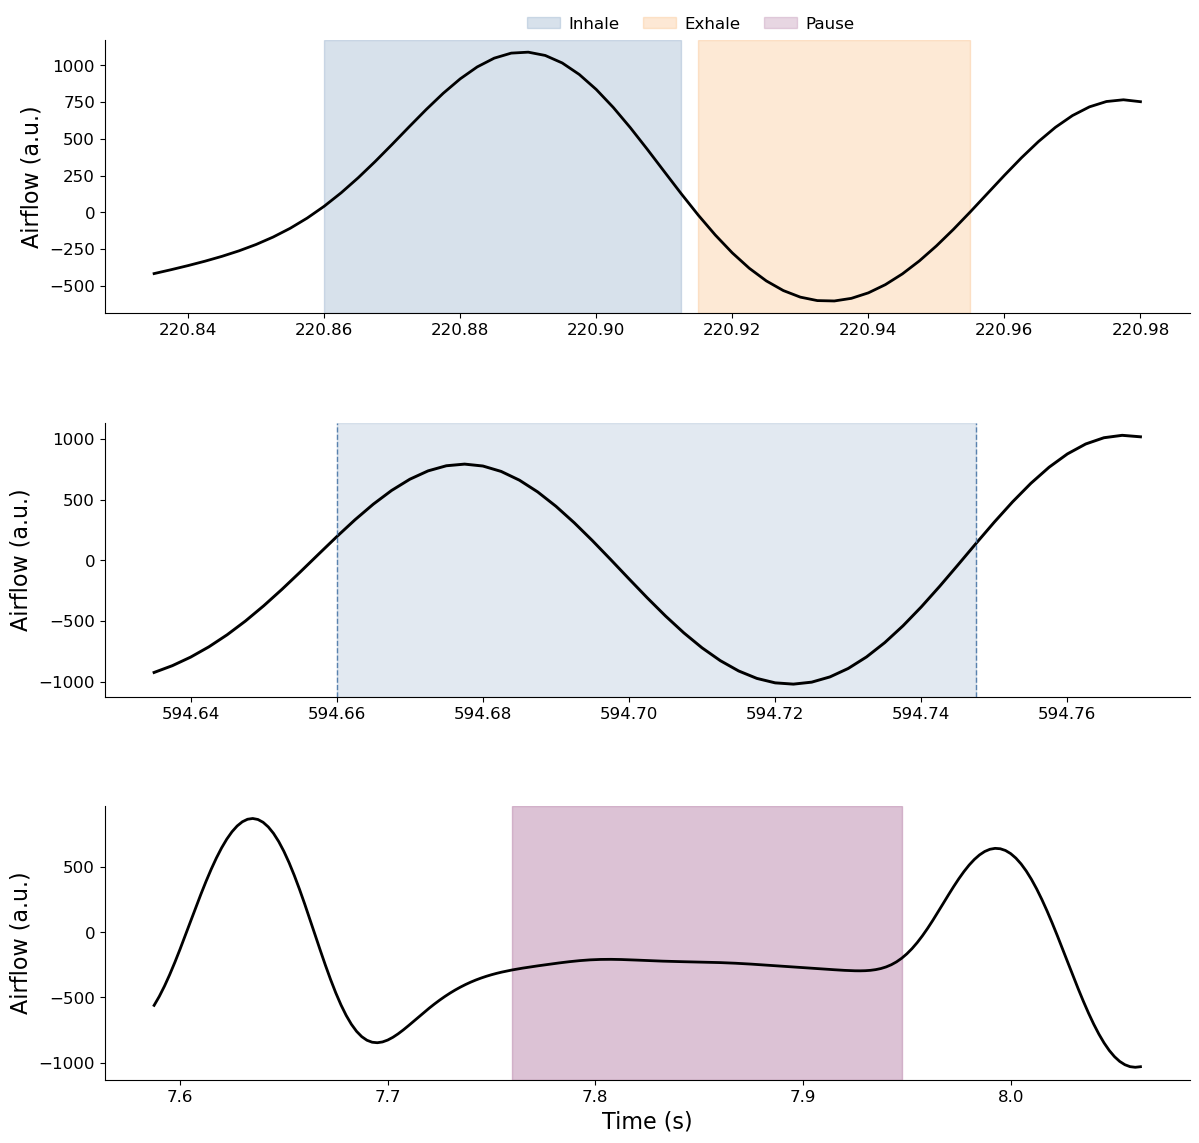

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def _as_1d_int_array(x, allow_nan=False):
    arr = np.asarray(x).ravel()
    if allow_nan:
        return arr.astype(float)
    return arr.astype(int)


def _get_attr_if_exists(obj, names, required=False, default=None):
    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name), name
    if required:
        raise AttributeError(f"Could not find any of these attributes on bm: {names}")
    return default, None


def _infer_bm_fields(bm, signal_len=None):
    inhale_onsets, inhale_on_name = _get_attr_if_exists(
        bm, ["inhaleOnsets", "inhale_onsets"], required=True
    )
    exhale_onsets, exhale_on_name = _get_attr_if_exists(
        bm, ["exhaleOnsets", "exhale_onsets"], required=True
    )
    inhale_offsets, inhale_off_name = _get_attr_if_exists(
        bm, ["inhaleOffsets", "inhale_offsets"], required=True
    )
    exhale_offsets, exhale_off_name = _get_attr_if_exists(
        bm, ["exhaleOffsets", "exhale_offsets"], required=True
    )

    inhale_pause_onsets, inhale_pause_name = _get_attr_if_exists(
        bm, ["inhalePauseOnsets", "inhale_pause_onsets"], required=False, default=None
    )
    exhale_pause_onsets, exhale_pause_name = _get_attr_if_exists(
        bm, ["exhalePauseOnsets", "exhale_pause_onsets"], required=False, default=None
    )

    inhale_peaks, inhale_peak_name = _get_attr_if_exists(
        bm, ["inhalePeaks", "inhale_peaks"], required=False, default=None
    )
    exhale_troughs, exhale_trough_name = _get_attr_if_exists(
        bm, ["exhaleTroughs", "exhale_troughs"], required=False, default=None
    )

    inh_on = _as_1d_int_array(inhale_onsets)
    exh_on = _as_1d_int_array(exhale_onsets)
    inh_off = _as_1d_int_array(inhale_offsets, allow_nan=True)
    exh_off = _as_1d_int_array(exhale_offsets, allow_nan=True)

    inh_pause = None if inhale_pause_onsets is None else _as_1d_int_array(inhale_pause_onsets, allow_nan=True)
    exh_pause = None if exhale_pause_onsets is None else _as_1d_int_array(exhale_pause_onsets, allow_nan=True)

    inh_peak = None if inhale_peaks is None else _as_1d_int_array(inhale_peaks)
    exh_trough = None if exhale_troughs is None else _as_1d_int_array(exhale_troughs)

    if signal_len is not None:
        inh_on = inh_on[(inh_on >= 0) & (inh_on < signal_len)]
        exh_on = exh_on[(exh_on >= 0) & (exh_on < signal_len)]

    fields = {
        "inhale_onsets": inh_on,
        "exhale_onsets": exh_on,
        "inhale_offsets": inh_off,
        "exhale_offsets": exh_off,
        "inhale_pause_onsets": inh_pause,
        "exhale_pause_onsets": exh_pause,
        "inhale_peaks": inh_peak,
        "exhale_troughs": exh_trough,
        "names": {
            "inhale_onsets": inhale_on_name,
            "exhale_onsets": exhale_on_name,
            "inhale_offsets": inhale_off_name,
            "exhale_offsets": exhale_off_name,
            "inhale_pause_onsets": inhale_pause_name,
            "exhale_pause_onsets": exhale_pause_name,
            "inhale_peaks": inhale_peak_name,
            "exhale_troughs": exhale_trough_name,
        }
    }
    return fields


def build_bm_breath_table(signal, time, bm):
    fields = _infer_bm_fields(bm, signal_len=len(signal))

    inh_on = fields["inhale_onsets"]
    exh_on = fields["exhale_onsets"]
    inh_off = fields["inhale_offsets"]
    exh_off = fields["exhale_offsets"]
    inh_pause = fields["inhale_pause_onsets"]
    exh_pause = fields["exhale_pause_onsets"]
    inh_peak = fields["inhale_peaks"]
    exh_trough = fields["exhale_troughs"]

    n = min(len(inh_on), len(exh_on), len(inh_off), len(exh_off))
    if inh_pause is not None:
        n = min(n, len(inh_pause))
    if exh_pause is not None:
        n = min(n, len(exh_pause))
    if inh_peak is not None:
        n = min(n, len(inh_peak))
    if exh_trough is not None:
        n = min(n, len(exh_trough))

    rows = []
    for i in range(n):
        a = int(inh_on[i])
        b = int(exh_on[i])
        c = inh_off[i]
        d = exh_off[i]

        if np.isnan(c) or np.isnan(d):
            continue

        c = int(c)
        d = int(d)

        if not (0 <= a < len(signal) and 0 <= b < len(signal) and 0 <= c < len(signal) and 0 <= d < len(signal)):
            continue

        inhale_pause_on = np.nan
        exhale_pause_on = np.nan

        if inh_pause is not None and i < len(inh_pause) and not np.isnan(inh_pause[i]):
            inhale_pause_on = int(inh_pause[i])

        if exh_pause is not None and i < len(exh_pause) and not np.isnan(exh_pause[i]):
            exhale_pause_on = int(exh_pause[i])

        peak_idx = np.nan
        trough_idx = np.nan

        if inh_peak is not None and i < len(inh_peak):
            peak_idx = int(inh_peak[i])

        if exh_trough is not None and i < len(exh_trough):
            trough_idx = int(exh_trough[i])

        next_inhale_on = np.nan
        if i + 1 < len(inh_on):
            next_inhale_on = int(inh_on[i + 1])

        inhale_dur = time[c] - time[a]
        exhale_dur = time[d] - time[b]

        inhale_pause_dur = np.nan
        if not np.isnan(inhale_pause_on):
            inhale_pause_dur = time[b] - time[int(inhale_pause_on)]

        exhale_pause_dur = np.nan
        if not np.isnan(exhale_pause_on) and not np.isnan(next_inhale_on):
            exhale_pause_dur = time[int(next_inhale_on)] - time[int(exhale_pause_on)]

        breath_dur = np.nan
        if not np.isnan(next_inhale_on):
            breath_dur = time[int(next_inhale_on)] - time[a]

        rows.append({
            "breath_idx": i,
            "inhale_on": a,
            "exhale_on": b,
            "inhale_off": c,
            "exhale_off": d,
            "inhale_pause_on": inhale_pause_on,
            "exhale_pause_on": exhale_pause_on,
            "inhale_peak": peak_idx,
            "exhale_trough": trough_idx,
            "next_inhale_on": next_inhale_on,
            "inhale_dur": float(inhale_dur),
            "exhale_dur": float(exhale_dur),
            "inhale_pause_dur": float(inhale_pause_dur) if not np.isnan(inhale_pause_dur) else np.nan,
            "exhale_pause_dur": float(exhale_pause_dur) if not np.isnan(exhale_pause_dur) else np.nan,
            "breath_dur": float(breath_dur) if not np.isnan(breath_dur) else np.nan,
        })

    if not rows:
        raise RuntimeError("No usable breaths found. BM arrays may be empty, mismatched, or out of bounds.")

    df = pd.DataFrame(rows)

    full_df = df.dropna(subset=["breath_dur"]).copy()
    if not full_df.empty:
        inhale_med = np.nanmedian(full_df["inhale_dur"])
        breath_med = np.nanmedian(full_df["breath_dur"])
        df["inhale_centrality"] = np.abs(df["inhale_dur"] - inhale_med)
        df["breath_centrality"] = np.abs(df["breath_dur"] - breath_med)
    else:
        df["inhale_centrality"] = np.nan
        df["breath_centrality"] = np.nan

    return df, fields


def choose_bm_examples(df):
    valid_inhale = df[(df["inhale_dur"] > 0.02) & (df["inhale_dur"] < 1.0)].copy()
    if valid_inhale.empty:
        valid_inhale = df.copy()
    valid_inhale = valid_inhale.sort_values("inhale_centrality", ascending=True)
    inhale_idx = int(valid_inhale.iloc[0]["breath_idx"])

    full_df = df.dropna(subset=["breath_dur"]).copy()
    if full_df.empty:
        full_df = df.copy()
    full_df = full_df.sort_values("breath_centrality", ascending=True)
    series_idx = int(full_df.iloc[min(len(full_df) // 3, len(full_df) - 1)]["breath_idx"])

    return {
        "combined": inhale_idx,
        "breath_rate_series_start": series_idx,
    }


def _find_breath_with_pause(df, max_pause_frac=0.6, min_pause_dur=0.02):
    def _best(subset, dur_col, ref_col="breath_dur"):
        subset = subset.copy()
        subset = subset[subset[dur_col] > min_pause_dur]
        subset = subset[subset[ref_col].notna() & (subset[ref_col] > 0)]
        subset["pause_frac"] = subset[dur_col] / subset[ref_col]
        subset = subset[subset["pause_frac"] < max_pause_frac]
        if subset.empty:
            return None
        return int(subset.sort_values("pause_frac", ascending=False).iloc[0]["breath_idx"])

    has_inhale = df[
        df["inhale_pause_on"].notna() &
        ~df["inhale_pause_on"].apply(np.isnan) &
        df["inhale_pause_dur"].notna()
    ]
    if not has_inhale.empty:
        result = _best(has_inhale, "inhale_pause_dur")
        if result is not None:
            return result

    has_exhale = df[
        df["exhale_pause_on"].notna() &
        ~df["exhale_pause_on"].apply(np.isnan) &
        df["exhale_pause_dur"].notna()
    ]
    if not has_exhale.empty:
        result = _best(has_exhale, "exhale_pause_dur")
        if result is not None:
            return result

    return None


def _segment_window(row, signal_len, pad_frac=0.22, min_pad=10):
    key_points = [
        int(row["inhale_on"]),
        int(row["exhale_on"]),
        int(row["inhale_off"]),
        int(row["exhale_off"]),
    ]
    if not np.isnan(row["next_inhale_on"]):
        key_points.append(int(row["next_inhale_on"]))

    lo = min(key_points)
    hi = max(key_points)
    pad = max(min_pad, int((hi - lo) * pad_frac))
    start = max(0, lo - pad)
    stop = min(signal_len, hi + pad)
    return start, stop


def _segment_window_pause(row, signal_len, pad_frac=0.20, min_pad=10, shift_sec=0.0, fs=None):
    key_points = [
        int(row["inhale_on"]),
        int(row["exhale_on"]),
        int(row["inhale_off"]),
        int(row["exhale_off"]),
    ]

    if not np.isnan(row["inhale_pause_on"]):
        key_points.append(int(row["inhale_pause_on"]))
    if not np.isnan(row["exhale_pause_on"]):
        key_points.append(int(row["exhale_pause_on"]))
    if not np.isnan(row["next_inhale_on"]):
        key_points.append(int(row["next_inhale_on"]))

    lo = min(key_points)
    hi = max(key_points)
    pad = max(min_pad, int((hi - lo) * pad_frac))
    start = max(0, lo - pad)
    stop = min(signal_len, hi + pad)

    # Positive shift_sec moves the viewing window later in time,
    # which makes the pause appear a bit more left/centered in the panel.
    if fs is not None and shift_sec != 0:
        shift_samples = int(round(shift_sec * fs))
        start = min(max(0, start + shift_samples), signal_len - 1)
        stop = min(max(start + 1, stop + shift_samples), signal_len)

    return start, stop


def _plot_combined_segmentation_and_inhale(ax, signal, time, row):
    start, stop = _segment_window(row, len(signal), pad_frac=0.25)
    t = time[start:stop]
    s = signal[start:stop]

    ax.plot(t, s, color="black", lw=2.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylabel("Airflow (a.u.)", fontsize=16)

    a = int(row["inhale_on"])
    b = int(row["exhale_on"])
    c = int(row["inhale_off"])
    d = int(row["exhale_off"])

    ax.axvspan(time[a], time[c], alpha=0.22, color="#4C78A8", label="Inhale")
    ax.axvspan(time[b], time[d], alpha=0.18, color="#F58518", label="Exhale")

    if not np.isnan(row["inhale_pause_on"]):
        p = int(row["inhale_pause_on"])
        ax.axvspan(time[p], time[b], alpha=0.30, color="#B279A2", label="Pause")

    if not np.isnan(row["exhale_pause_on"]) and not np.isnan(row["next_inhale_on"]):
        p = int(row["exhale_pause_on"])
        nxt = int(row["next_inhale_on"])
        ax.axvspan(time[p], time[nxt], alpha=0.30, color="#B279A2", label="Pause")

    ax.tick_params(axis="both", labelsize=12)


def _plot_breath_rate(ax, signal, time, df, start_breath_idx):
    full_df = df.dropna(subset=["breath_dur"]).copy().sort_values("breath_idx")
    if full_df.empty:
        raise RuntimeError("No full breath cycles available for breath-rate plot.")

    breath_ids = full_df["breath_idx"].astype(int).tolist()
    start_pos = breath_ids.index(start_breath_idx) if start_breath_idx in breath_ids else 0

    selected = full_df.iloc[start_pos:start_pos + 3].copy()
    if len(selected) < 3:
        selected = full_df.iloc[max(0, len(full_df) - 3):].copy()
    if len(selected) < 3:
        selected = full_df.iloc[:3].copy()

    if len(selected) < 2:
        raise RuntimeError("Need at least 2 consecutive inhale onsets for breath-rate plot.")

    mid_row = selected.iloc[1] if len(selected) >= 3 else selected.iloc[0]

    a_mid = int(mid_row["inhale_on"])
    nxt_mid = int(mid_row["next_inhale_on"])

    one_breath_len = max(1, nxt_mid - a_mid)
    pad = max(10, int(0.20 * one_breath_len))
    start = max(0, a_mid - pad)
    stop = min(len(signal), nxt_mid + pad)

    t = time[start:stop]
    s = signal[start:stop]

    ax.plot(t, s, color="black", lw=2.1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylabel("Airflow (a.u.)", fontsize=16)

    ax.axvline(time[a_mid], color="#4C78A8", ls="--", lw=1.0, alpha=0.9)
    ax.axvline(time[nxt_mid], color="#4C78A8", ls="--", lw=1.0, alpha=0.9)
    ax.axvspan(time[a_mid], time[nxt_mid], alpha=0.16, color="#4C78A8")

    ax.tick_params(axis="both", labelsize=12)


def _plot_respiratory_pause(ax, signal, time, row, fs, shift_sec=0.05):
    start, stop = _segment_window_pause(
        row,
        len(signal),
        pad_frac=0.20,
        shift_sec=shift_sec,
        fs=fs
    )
    t = time[start:stop]
    s = signal[start:stop]

    ax.plot(t, s, color="black", lw=2.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylabel("Airflow (a.u.)", fontsize=16)

    pause_fill = "#B279A2"

    if not np.isnan(row["inhale_pause_on"]):
        p = int(row["inhale_pause_on"])
        b = int(row["exhale_on"])
        ax.axvspan(time[p], time[b], alpha=0.45, color=pause_fill)

    if not np.isnan(row["exhale_pause_on"]) and not np.isnan(row["next_inhale_on"]):
        p = int(row["exhale_pause_on"])
        nxt = int(row["next_inhale_on"])
        ax.axvspan(time[p], time[nxt], alpha=0.45, color=pause_fill)

    ax.tick_params(axis="both", labelsize=12)


def plot_true_bm_feature_examples(signal, time, bm, figsize=(14, 13), pause_breath_idx=None):
    df, fields = build_bm_breath_table(signal, time, bm)
    selected = choose_bm_examples(df)

    print("Using BM fields:", fields["names"])
    print("Selected breaths:", selected)

    by_idx = {int(r["breath_idx"]): r for _, r in df.iterrows()}

    if pause_breath_idx is None:
        pause_breath_idx = _find_breath_with_pause(df)
    has_pause_panel = pause_breath_idx is not None
    n_panels = 3 if has_pause_panel else 2

    fig, axes = plt.subplots(n_panels, 1, figsize=figsize, sharex=False, facecolor="none")
    if n_panels == 1:
        axes = [axes]

    fig.subplots_adjust(hspace=0.40, top=0.88, bottom=0.08)

    _plot_combined_segmentation_and_inhale(
        axes[0], signal, time, by_idx[selected["combined"]]
    )

    _plot_breath_rate(
        axes[1], signal, time, df, selected["breath_rate_series_start"]
    )

    if has_pause_panel:
        fs = 1.0 / np.median(np.diff(time))
        _plot_respiratory_pause(
            axes[2], signal, time, by_idx[pause_breath_idx], fs=fs, shift_sec=0.05
        )

    legend_handles = [
        mpatches.Patch(color="#4C78A8", alpha=0.22, label="Inhale"),
        mpatches.Patch(color="#F58518", alpha=0.18, label="Exhale"),
    ]

    if has_pause_panel:
        legend_handles.append(
            mpatches.Patch(color="#B279A2", alpha=0.30, label="Pause")
        )

    axes[0].legend(
        handles=legend_handles,
        frameon=False,
        ncol=len(legend_handles),
        loc="upper center",
        bbox_to_anchor=(0.54, 1.14),
        fontsize=12,
        columnspacing=1.4,
        handletextpad=0.5,
    )

    axes[-1].set_xlabel("Time (s)", fontsize=16)
    fig.patch.set_alpha(0.0)
    plt.show()
    return df, selected, fig


# ── Run only final plot ─────────────────────────────────────────────
trial = "RI1_1_2"
h5_path = resp_paths_interactions[trial]

signal, time, fs, meta = load_clean_resp_signal(h5_path, target_rate=400)
bm = fit_bm_session(signal, fs, data_type="rodentAirflow")

feature_df, chosen_examples, fig = plot_true_bm_feature_examples(
    signal, time, bm, pause_breath_idx=45
)

fig.savefig(
    "breathmetrics_features.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

In [31]:
def inspect_pause_candidates(df, max_pause_frac=0.6, min_pause_dur=0.02, n=10):
    """
    Print a ranked table of pause candidates so you can manually pick a good one.
    Call this before plot_true_bm_feature_examples to choose a breath_idx to hardcode.
    """
    rows = []

    for _, r in df.iterrows():
        if (
            not np.isnan(r["inhale_pause_on"]) and
            not np.isnan(r["inhale_pause_dur"]) and
            r["inhale_pause_dur"] > min_pause_dur and
            not np.isnan(r["breath_dur"]) and
            r["breath_dur"] > 0
        ):
            frac = r["inhale_pause_dur"] / r["breath_dur"]
            if frac < max_pause_frac:
                rows.append({
                    "breath_idx": int(r["breath_idx"]),
                    "type": "inhale pause",
                    "pause_dur_s": round(r["inhale_pause_dur"], 3),
                    "breath_dur_s": round(r["breath_dur"], 3),
                    "pause_frac": round(frac, 3),
                    "inhale_on_s": round(time[int(r["inhale_on"])], 3),
                })

        if (
            not np.isnan(r["exhale_pause_on"]) and
            not np.isnan(r["exhale_pause_dur"]) and
            r["exhale_pause_dur"] > min_pause_dur and
            not np.isnan(r["breath_dur"]) and
            r["breath_dur"] > 0
        ):
            frac = r["exhale_pause_dur"] / r["breath_dur"]
            if frac < max_pause_frac:
                rows.append({
                    "breath_idx": int(r["breath_idx"]),
                    "type": "exhale pause",
                    "pause_dur_s": round(r["exhale_pause_dur"], 3),
                    "breath_dur_s": round(r["breath_dur"], 3),
                    "pause_frac": round(frac, 3),
                    "inhale_on_s": round(time[int(r["inhale_on"])], 3),
                })

    if not rows:
        print("No valid pause candidates found.")
        return None

    cand_df = (
        pd.DataFrame(rows)
        .sort_values("pause_frac", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )
    display(cand_df)
    return cand_df